A width x height grid is on an XY-plane with the bottom-left cell at (0, 0) and the top-right cell at (width - 1, height - 1). The grid is aligned with the four cardinal directions ("North", "East", "South", and "West"). A robot is initially at cell (0, 0) facing direction "East".

The robot can be instructed to move for a specific number of steps. For each step, it does the following.

    Attempts to move forward one cell in the direction it is facing.
    If the cell the robot is moving to is out of bounds, the robot instead turns 90 degrees counterclockwise and retries the step.

After the robot finishes moving the number of steps required, it stops and awaits the next instruction.

Implement the Robot class:

    Robot(int width, int height) Initializes the width x height grid with the robot at (0, 0) facing "East".
    void step(int num) Instructs the robot to move forward num steps.
    int[] getPos() Returns the current cell the robot is at, as an array of length 2, [x, y].
    String getDir() Returns the current direction of the robot, "North", "East", "South", or "West".

 

Example 1:
example-1

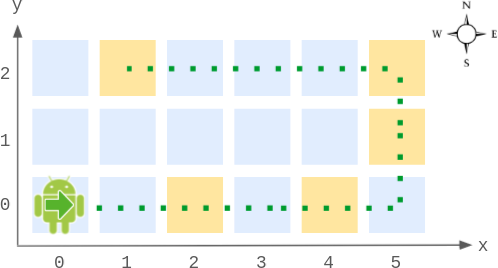

Input
["Robot", "step", "step", "getPos", "getDir", "step", "step", "step", "getPos", "getDir"]
[[6, 3], [2], [2], [], [], [2], [1], [4], [], []]
Output
[null, null, null, [4, 0], "East", null, null, null, [1, 2], "West"]

Explanation
Robot robot = new Robot(6, 3); // Initialize the grid and the robot at (0, 0) facing East.
robot.step(2);  // It moves two steps East to (2, 0), and faces East.
robot.step(2);  // It moves two steps East to (4, 0), and faces East.
robot.getPos(); // return [4, 0]
robot.getDir(); // return "East"
robot.step(2);  // It moves one step East to (5, 0), and faces East.
                // Moving the next step East would be out of bounds, so it turns and faces North.
                // Then, it moves one step North to (5, 1), and faces North.
robot.step(1);  // It moves one step North to (5, 2), and faces North (not West).
robot.step(4);  // Moving the next step North would be out of bounds, so it turns and faces West.
                // Then, it moves four steps West to (1, 2), and faces West.
robot.getPos(); // return [1, 2]
robot.getDir(); // return "West"

 

Constraints:

    2 <= width, height <= 100
    1 <= num <= 105
    At most 104 calls in total will be made to step, getPos, and getDir.



In [ ]:
# TLE

class Robot:

    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.x = 0
        self.y = 0
        self.counter = 0
        self.direction = 0
        

    def step(self, num: int) -> None:
        self.counter += num

    def getPos(self) -> List[int]:
        while self.counter > 0:
            if self.direction == 0:
                diff = min(self.width - 1 - self.x, self.counter)
                self.counter -= diff
                self.x += diff
            elif self.direction == 1:
                diff = min(self.height - 1 - self.y, self.counter)
                self.counter -= diff
                self.y += diff
            elif self.direction == 2:
                diff = min(self.x, self.counter)
                self.counter -= diff
                self.x -= diff
            elif self.direction == 3:
                diff = min(self.y, self.counter)
                self.counter -= diff
                self.y -= diff
            if self.counter > 0:
                self.direction = (self.direction + 1) % 4
        return self.x, self.y

    def getDir(self) -> str:
        if self.counter > 0:
            self.getPos()
        return ["East", "North", "West", "South"][self.direction]
        


# Your Robot object will be instantiated and called as such:
# obj = Robot(width, height)
# obj.step(num)
# param_2 = obj.getPos()
# param_3 = obj.getDir()

In [ ]:
class Robot:
    TO_DIR = {
        0: "East",
        1: "North",
        2: "West",
        3: "South",
    }
    def __init__(self, width: int, height: int):
        self.moved = False
        self.idx = 0
        self.pos = list()
        self.dirs = list()

        pos_, dirs_ = self.pos, self.dirs

        for i in range(width):
            pos_.append((i, 0))
            dirs_.append(0)
        for i in range(1, height):
            pos_.append((width - 1, i))
            dirs_.append(1)
        for i in range(width - 2, -1, -1):
            pos_.append((i, height - 1))
            dirs_.append(2)
        for i in range(height - 2, 0, -1):
            pos_.append((0, i))
            dirs_.append(3)

        dirs_[0] = 3
        

    def step(self, num: int) -> None:
        self.moved = True
        self.idx = (self.idx + num) % len(self.pos)

    def getPos(self) -> List[int]:
        return list(self.pos[self.idx])

    def getDir(self) -> str:
        if not self.moved:
            return "East"
        return Robot.TO_DIR[self.dirs[self.idx]]
        


# Your Robot object will be instantiated and called as such:
# obj = Robot(width, height)
# obj.step(num)
# param_2 = obj.getPos()
# param_3 = obj.getDir()